In [ ]:
import qiskit



---

# The Bell States

## 1. Theory: What is a Bell State?

A **Bell State** is the simplest and most perfect example of quantum entanglement. It involves two qubits that are so strongly connected that they lose their individual identities.

There are **4 Bell States**, but the most famous one is **** (Phi-Plus).

**The Formula:**


**What does this mean?**

* The system is in a superposition of being **both** `00` and `11` at the same time.
* **Perfect Correlation:** If you measure the first qubit and get **0**, the second qubit is **guaranteed** to be **0**. If you get **1**, the second is **guaranteed** to be **1**.
* There is **0% chance** of getting `01` or `10`.

---

## 2. Code: Creating the Bell State

Here is the Python (Qiskit) code to create the standard Bell State.

**The Recipe:**

1. **H-Gate** on Qubit 0 (Creates Superposition).
2. **CNOT Gate** (Control: Qubit 0, Target: Qubit 1).

Circuit Diagram:


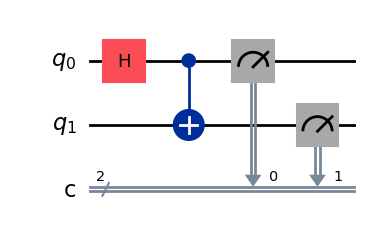


Measurement Results: {'11': 529, '00': 495}


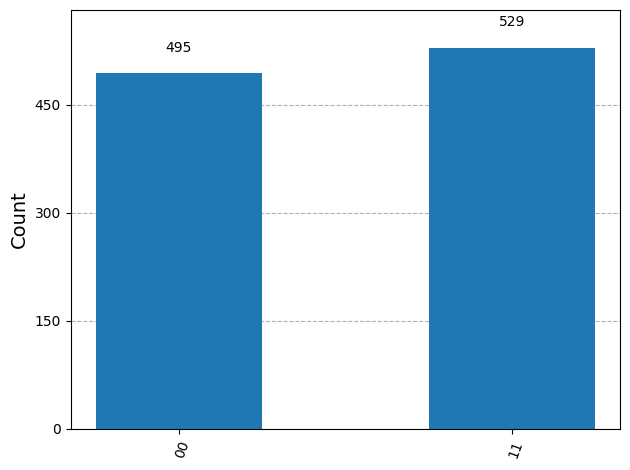

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Step 1: Initialize a circuit with 2 Qubits and 2 Classical Bits
qc = QuantumCircuit(2, 2)

# Step 2: Apply H-gate to Qubit 0
# This puts Qubit 0 into state: 50% |0> and 50% |1>
qc.h(0)

# Step 3: Apply CNOT gate
# Control is Qubit 0, Target is Qubit 1
# If Q0 is 0, Q1 stays 0. If Q0 is 1, Q1 flips to 1.
qc.cx(0, 1)

# Step 4: Measure both qubits
qc.measure([0, 1], [0, 1])

# --- Visualize the Circuit ---
print("Circuit Diagram:")
display(qc.draw('mpl'))

# --- Run the Simulation ---
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# --- Show Results ---
print("\nMeasurement Results:", counts)
# You should see ~50% '00' and ~50% '11'
display(plot_histogram(counts))



## 3. Exercises (Homework)

To truly master this, try these modifications:

### Exercise 1: The "Opposite" Bell State ()

**Goal:** Create a state where the qubits are perfectly **anti-correlated**. (If one is 0, the other is 1).

* **Formula:** 
* **Hint:** Add an **X-gate** to Qubit 1 *before* applying the H and CNOT gates.
* **Expected Output:** Histogram shows only `01` and `10`.

### Exercise 2: The GHZ State (3-Qubit Entanglement)

**Goal:** Entangle three qubits instead of two.

* **Formula:** 
* **Hint:**
1. Initialize `QuantumCircuit(3, 3)`.
2. Apply **H-gate** on Qubit 0.
3. Apply **CNOT** (Control 0, Target 1).
4. Apply **CNOT** (Control 1, Target 2).


* **Expected Output:** Histogram shows only `000` and `111`.

--- Instructor Note (For your tutorial explanation)

When explaining the CNOT part, tell your audience:

> "Think of the H-gate as creating a *choice* (Head or Tail). The CNOT gate forces the second qubit to *copy* that choice instantly. That is how they become linked."